C:\Users\Marcel\AppData\Local\Temp\ipykernel_1632\42367907.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


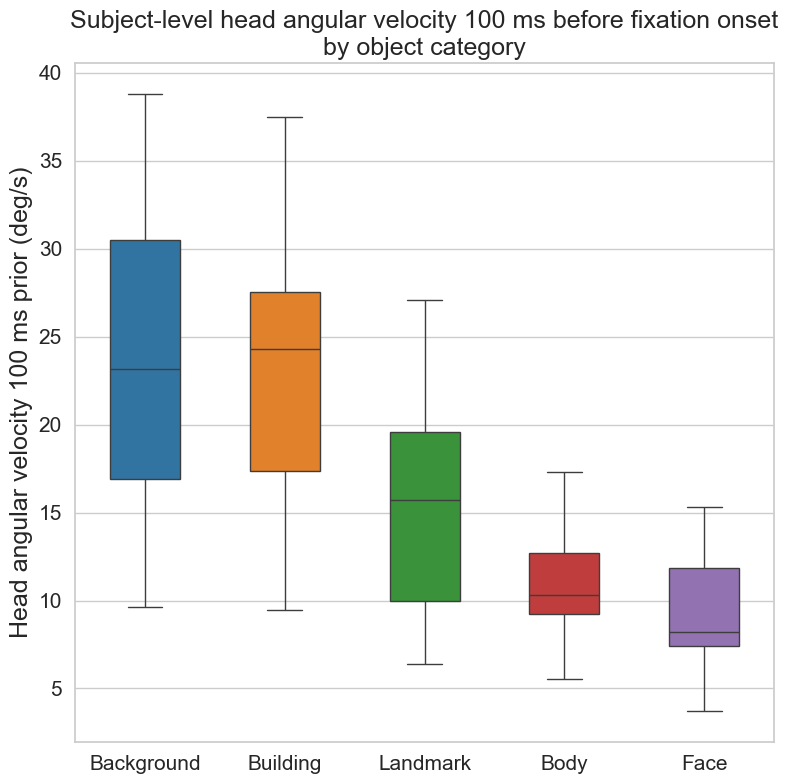

C:\Users\Marcel\AppData\Local\Temp\ipykernel_1632\42367907.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


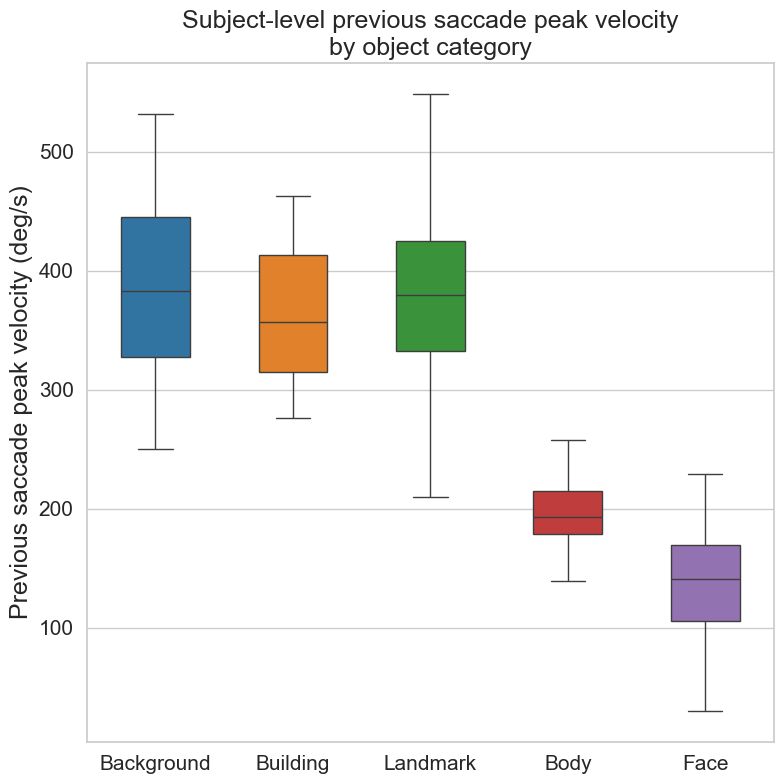

C:\Users\Marcel\AppData\Local\Temp\ipykernel_1632\42367907.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


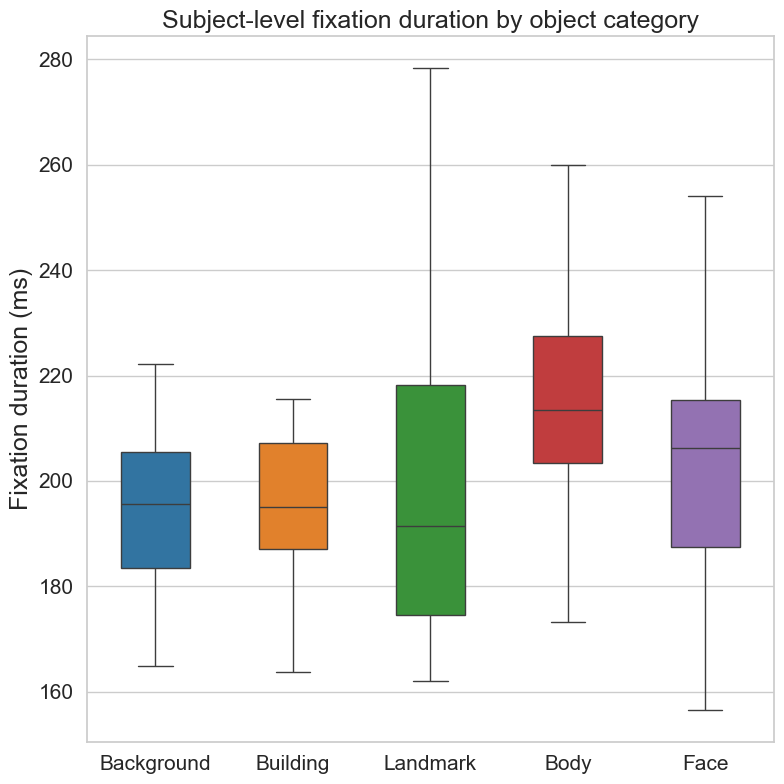

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

# -------------------------------------------------------------------
# 0. Basic setup
# -------------------------------------------------------------------
sns.set(style="whitegrid")

# -------------------------------------------------------------------
# 1. Load data and basic preprocessing
# -------------------------------------------------------------------
csv_path = r"C:\Users\Marcel\Desktop\Study Project\VR Data\ctx_fixations.csv"

ctx_fixations = pd.read_csv(csv_path)

# Convert seconds → milliseconds, matching your R code
ctx_fixations["length_ms"] = ctx_fixations["length"] * 1000

cat_col = "ObjectCategoryMerged"
subj_col = "SubjectID"

# Desired category order and colors
desired_order = ["Background", "Building", "Landmark", "Body", "Face"]

palette_vals = {
    "Background": "#1f77b4",
    "Building":   "#ff7f0e",
    "Landmark":   "#2ca02c",
    "Body":       "#d62728",
    "Face":       "#9467bd"
}

# -------------------------------------------------------------------
# 2. Helper: prepare subject-level means per category
# -------------------------------------------------------------------
def prepare_subject_means(df, dv_col, cat_col, subj_col, desired_order):
    """
    Parameters
    ----------
    df : pandas.DataFrame
        Full ctx_fixations DataFrame.
    dv_col : str
        Name of the dependent variable column.
    cat_col : str
        Name of the category column.
    subj_col : str
        Name of the subject column.
    desired_order : list[str]
        Desired category order.

    Returns
    -------
    tuple[pandas.DataFrame, list[str]]
        subject-level means DataFrame and present levels list.
    """
    sub = df[[subj_col, cat_col, dv_col]].copy()
    sub = sub.dropna(subset=[dv_col, cat_col])

    present_levels = [c for c in desired_order if c in sub[cat_col].unique()]
    cat_type = CategoricalDtype(categories=present_levels, ordered=True)
    sub[cat_col] = sub[cat_col].astype(cat_type)

    subj_means = (
        sub
        .groupby([subj_col, cat_col], as_index=False, observed=True)[dv_col]
        .mean()
        .rename(columns={dv_col: "mean_value"})
    )

    return subj_means, present_levels

# -------------------------------------------------------------------
# 3. Helper: plotting function (boxplot only)
# -------------------------------------------------------------------
def plot_subject_box(subject_means,
                     cat_col,
                     value_col,
                     levels,
                     palette_vals,
                     y_label,
                     title):
    """
    Creates one seaborn boxplot figure using subject-level means.
    """
    palette_used = {level: palette_vals[level] for level in levels}

    plt.figure(figsize=(8, 8))

    ax = sns.boxplot(
        data=subject_means,
        x=cat_col,
        y=value_col,
        order=levels,
        palette=palette_used,
        width=0.5,
        showfliers=False
    )

    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=18)
    ax.set_title(title, fontsize=18)

    ax.tick_params(axis="x", labelsize=15)
    ax.tick_params(axis="y", labelsize=15)

    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------------
# 4. HEAD VELOCITY: 100 ms prior to fixation
# -------------------------------------------------------------------
head_means, head_levels = prepare_subject_means(
    df=ctx_fixations,
    dv_col="head_vel_100ms_prior",
    cat_col=cat_col,
    subj_col=subj_col,
    desired_order=desired_order
)

plot_subject_box(
    subject_means=head_means,
    cat_col=cat_col,
    value_col="mean_value",
    levels=head_levels,
    palette_vals=palette_vals,
    y_label="Head angular velocity 100 ms prior (deg/s)",
    title="Subject-level head angular velocity 100 ms before fixation onset\nby object category"
)

# -------------------------------------------------------------------
# 5. PREVIOUS SACCADE PEAK VELOCITY
# -------------------------------------------------------------------
peak_means, peak_levels = prepare_subject_means(
    df=ctx_fixations,
    dv_col="prev_saccade_peak_velocity_deg_per_s",
    cat_col=cat_col,
    subj_col=subj_col,
    desired_order=desired_order
)

plot_subject_box(
    subject_means=peak_means,
    cat_col=cat_col,
    value_col="mean_value",
    levels=peak_levels,
    palette_vals=palette_vals,
    y_label="Previous saccade peak velocity (deg/s)",
    title="Subject-level previous saccade peak velocity\nby object category"
)

# -------------------------------------------------------------------
# 6. FIXATION DURATION: length_ms
# -------------------------------------------------------------------
len_means, len_levels = prepare_subject_means(
    df=ctx_fixations,
    dv_col="length_ms",
    cat_col=cat_col,
    subj_col=subj_col,
    desired_order=desired_order
)

plot_subject_box(
    subject_means=len_means,
    cat_col=cat_col,
    value_col="mean_value",
    levels=len_levels,
    palette_vals=palette_vals,
    y_label="Fixation duration (ms)",
    title="Subject-level fixation duration by object category"
)